# Comprehensive Analysis of Developer Market Trends & Salary Drivers
## Phase 1: Data Wrangling & Engineering

### Business Context & Problem Statement
This project explores trends in the global IT workforce market, identifying core factors that drive developer compensation and job satisfaction, based on a large-scale developer survey.

**Phase Objectives:**
1. Detect and remove duplicate records to ensure data integrity.
2. Assess and handle missing values with a strategy tailored to each variable's role in the analysis.
3. Standardize inconsistent categorical formatting and encode categorical variables.
4. Engineer new features and normalize skewed numerical variables.

**Central Research Questions** (carried through Phase 2 — EDA and Phase 3 — Modeling):
1. **Data Quality & Representativeness:** Who took the survey, and how reliable is the salary data (~64% missing)?
2. **Income Distribution:** How is developer compensation distributed, and how are outliers identified?
3. **Salary Drivers:** How do country, years of experience, education level, employment type, and remote-work arrangement affect compensation?
4. **Market Trends:** Which programming languages are most used, which are most wanted (Want vs. Have), and which command the highest median salaries?
5. **Income–Satisfaction Link:** Does job satisfaction (`JobSat`) increase with compensation and experience?

**Scope:** the raw survey contains 100+ columns. To keep this notebook focused and demonstrate each wrangling technique clearly, it works with the columns most relevant to the compensation/market-trend questions: `ResponseId`, `Country`, `EdLevel`, `Employment`, `RemoteWork`, `CodingActivities`, `YearsCodePro`, `CompTotal`, `ConvertedCompYearly`. Remaining columns are left untouched here and will be wrangled individually when they are needed for a specific analysis. In particular, `JobSat` and the other fields needed for Research Questions 4–5 (`WorkExp`, `Age`, `DevType`, `Industry`, `LanguageHaveWorkedWith`, `LanguageWantToWorkWith`) are **not** processed in this phase — they are pulled from `survey_data_deduplicated_full.csv` and wrangled in Phase 2 (EDA).

### 1. Environment Initialization & Data Ingestion
The raw dataset is expected to already be present locally at `data/survey_data_duplicates.csv` — place it there manually before running this notebook.

`DATA_DIR` points to a `data/` folder shared by all phases at the repo root. Adjust it if this notebook lives somewhere other than a `phase1_.../` subfolder one level below the repo root.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = '../data'  # shared data folder at repo root; use 'data' if running from the repo root itself
file_path = f'{DATA_DIR}/survey_data_duplicates.csv'

df_raw = pd.read_csv(file_path)
print(f"Raw shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Raw shape: 65447 rows, 114 columns


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### 2. Duplicate Detection & Removal
Duplicate detection is done on the full raw record (all columns), before narrowing down to the working column set.

In [2]:
dup_count = df_raw.duplicated().sum()
print(f"Number of fully duplicated rows: {dup_count}")

df_raw[df_raw.duplicated(keep=False)].sort_values('ResponseId').head(10)

Number of fully duplicated rows: 10


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [3]:
rows_before = df_raw.shape[0]
df_raw = df_raw.drop_duplicates()
rows_after = df_raw.shape[0]

print(f"Rows before: {rows_before} | Rows after: {rows_after} | Removed: {rows_before - rows_after}")
print(f"Duplicate rows remaining: {df_raw.duplicated().sum()}")

Rows before: 65447 | Rows after: 65437 | Removed: 10
Duplicate rows remaining: 0


Save the full, deduplicated dataset (all 114 columns) separately from the core-column output produced later in this notebook. This gives later phases a consistent, duplicate-free base to pull any additional column from, without needing to re-run duplicate detection.

In [4]:
full_output_path = f'{DATA_DIR}/survey_data_deduplicated_full.csv'
df_raw.to_csv(full_output_path, index=False)

print(f"Saved full deduplicated dataset ({df_raw.shape[0]} rows x {df_raw.shape[1]} columns) to '{full_output_path}'")

Saved full deduplicated dataset (65437 rows x 114 columns) to '../data/survey_data_deduplicated_full.csv'


### 3. Column Selection
Narrow down to the core columns used for the compensation/market-trend analysis in this notebook.

In [5]:
key_columns = [
    'ResponseId', 'Country', 'EdLevel', 'Employment', 'RemoteWork',
    'CodingActivities', 'YearsCodePro', 'CompTotal', 'ConvertedCompYearly'
]
df = df_raw[key_columns].copy()
df.shape

(65437, 9)

### 4. Missing Value Profiling
Check the missing-value rate for each of the core columns before deciding how to treat each one.

In [6]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False).round(2)
missing_pct

ConvertedCompYearly    64.19
CompTotal              48.44
YearsCodePro           21.13
CodingActivities       16.77
RemoteWork             16.25
Country                 9.94
EdLevel                 7.11
ResponseId              0.00
Employment              0.00
dtype: float64

### 5. Formatting Standardization
`Country` and `EdLevel` contain long, inconsistently formatted free-text categories. Standardize the most common variants into cleaner labels.

In [7]:
country_map = {
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Iran, Islamic Republic of...": "Iran",
    "Venezuela, Bolivarian Republic of...": "Venezuela",
    "Republic of North Macedonia": "North Macedonia",
    "United Republic of Tanzania": "Tanzania",
    "Lao People's Democratic Republic": "Laos",
    "Democratic People's Republic of Korea": "North Korea",
    "Democratic Republic of the Congo": "DR Congo",
    "Congo, Republic of the...": "Republic of the Congo",
    "Micronesia, Federated States of...": "Micronesia",
}
df['Country_clean'] = df['Country'].replace(country_map)

edlevel_map = {
    "Primary/elementary school": "Primary school",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secondary school",
    "Some college/university study without earning a degree": "Some college, no degree",
    "Associate degree (A.A., A.S., etc.)": "Associate degree",
    "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": "Bachelor's degree",
    "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's degree",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional/Doctoral degree",
    "Something else": "Other",
}
df['EdLevel_clean'] = df['EdLevel'].replace(edlevel_map)

print(f"Unique countries after standardization: {df['Country_clean'].nunique()}")
print(f"Unique education levels after standardization: {df['EdLevel_clean'].nunique()}")

Unique countries after standardization: 184
Unique education levels after standardization: 8


### 6. Categorical Variable Encoding
`Employment` is a multi-select field (values separated by `;`). One-hot encode it into binary columns.

In [8]:
employment_dummies = df['Employment'].str.get_dummies(';')
df = pd.concat([df, employment_dummies], axis=1)

df.head()

,ResponseId,Country,EdLevel,Employment,RemoteWork,CodingActivities,YearsCodePro,CompTotal,ConvertedCompYearly,Country_clean,EdLevel_clean,"Employed, full-time","Employed, part-time",I prefer not to say,"Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time"
0,1,United States of America,Primary/elementary school,"Employed, full-time",Remote,Hobby,NaN,NaN,NaN,United States of America,Primary school,1,0,0,0,0,0,0,0,0
1,2,United Kingdom of Great Britain and Northern I...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,17,NaN,NaN,United Kingdom,Bachelor's degree,1,0,0,0,0,0,0,0,0
2,3,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,27,NaN,NaN,United Kingdom,Master's degree,1,0,0,0,0,0,0,0,0
3,4,Canada,Some college/university study without earning ...,"Student, full-time",NaN,NaN,NaN,NaN,NaN,Canada,"Some college, no degree",0,0,0,0,0,0,0,1,0
4,5,Norway,"Secondary school (e.g. American high school, G...","Student, full-time",NaN,NaN,NaN,NaN,NaN,Norway,Secondary school,0,0,0,0,0,0,0,1,0


### 7. Missing Value Imputation
Each column is handled according to its missing rate and its role in the analysis:

- **`RemoteWork`, `EdLevel_clean`, `CodingActivities`** — moderate missing rate, and a "typical" answer is a meaningful stand-in → imputed with the **mode**.
- **`Country_clean`** — missing rate is non-trivial, but filling nationality with the most common country would systematically bias any geographic analysis → filled with an explicit **"Not specified"** label instead of the mode.
- **`YearsCodePro`** — converted to numeric; missing values are **left as `NaN`** (not imputed), since they feed directly into the `ExperienceLevel` feature engineered in the next step.
- **`CompTotal`, `ConvertedCompYearly`** — missing rate is very high (see Section 4). Imputing with mean/median here would fabricate the majority of the target variable and distort its distribution, so both are **left as `NaN`, not imputed**. A `has_compensation_data` flag is added so downstream analysis can explicitly account for it.

In [9]:
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
df['EdLevel_clean'] = df['EdLevel_clean'].fillna(df['EdLevel_clean'].mode()[0])
df['CodingActivities'] = df['CodingActivities'].fillna(df['CodingActivities'].mode()[0])
df['Country_clean'] = df['Country_clean'].fillna('Not specified')

df[['RemoteWork', 'EdLevel_clean', 'CodingActivities', 'Country_clean']].isnull().sum()

RemoteWork          0
EdLevel_clean       0
CodingActivities    0
Country_clean       0
dtype: int64

In [10]:
df['has_compensation_data'] = df['ConvertedCompYearly'].notnull()

print(df['has_compensation_data'].value_counts())
print(f"ConvertedCompYearly missing rate (kept as NaN): {df['ConvertedCompYearly'].isnull().mean()*100:.2f}%")
print(f"CompTotal missing rate (kept as NaN): {df['CompTotal'].isnull().mean()*100:.2f}%")

has_compensation_data
False    42002
True     23435
Name: count, dtype: int64
ConvertedCompYearly missing rate (kept as NaN): 64.19%
CompTotal missing rate (kept as NaN): 48.44%


### 8. Feature Engineering — Experience Level
Convert the continuous `YearsCodePro` field into a categorical `ExperienceLevel` feature for grouping and reporting.

In [11]:
df['YearsCodePro_num'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})
df['YearsCodePro_num'] = pd.to_numeric(df['YearsCodePro_num'], errors='coerce')

bins = [-1, 2, 5, 10, np.inf]
labels = ['Entry-level', 'Junior', 'Mid-level', 'Senior']
df['ExperienceLevel'] = pd.cut(df['YearsCodePro_num'], bins=bins, labels=labels)

df['ExperienceLevel'].value_counts(dropna=False)

ExperienceLevel
Senior         18460
NaN            13827
Mid-level      12653
Junior         10834
Entry-level     9663
Name: count, dtype: int64

### 9. Distribution Normalization
`ConvertedCompYearly` is expected to be heavily right-skewed. A log-transform is applied first to reduce skewness, then Min-Max and Z-score scaling are both computed on the **log-transformed** values for comparison — scaling the raw, still-skewed column directly would only compress the same skewed shape into a smaller range without correcting it. All steps operate only on non-missing values; the `NaN`s left from Section 7 are preserved.

**Disclaimer:** `ConvertedCompYearly_MinMax_experimental` and `ConvertedCompYearly_Zscore_experimental` below are an early technical trial, computed *before* outlier isolation. The `_experimental` suffix is intentional: Phase 2 (EDA) treats compensation outliers explicitly (flagging, not deleting) and Phase 3 (Modeling) will recompute the official scaled features — under different column names — after that outlier work. Do not reuse these two columns as final model inputs.


In [12]:
comp_valid = df['ConvertedCompYearly'].dropna()
skew_before = comp_valid.skew()
print(f"Skewness before transformation: {skew_before:.2f}")

df['ConvertedCompYearly_log'] = np.log1p(df['ConvertedCompYearly'])
skew_after_log = df['ConvertedCompYearly_log'].dropna().skew()
print(f"Skewness after log-transform: {skew_after_log:.2f}")

Skewness before transformation: 52.92
Skewness after log-transform: -2.26


In [13]:
log_valid = df['ConvertedCompYearly_log'].dropna()

df.loc[log_valid.index, 'ConvertedCompYearly_MinMax_experimental'] = (
    (log_valid - log_valid.min()) / (log_valid.max() - log_valid.min())
)
df.loc[log_valid.index, 'ConvertedCompYearly_Zscore_experimental'] = (
    (log_valid - log_valid.mean()) / log_valid.std()
)

df[['ConvertedCompYearly', 'ConvertedCompYearly_log', 'ConvertedCompYearly_MinMax_experimental', 'ConvertedCompYearly_Zscore_experimental']].describe()


,ConvertedCompYearly,ConvertedCompYearly_log,ConvertedCompYearly_MinMax,ConvertedCompYearly_Zscore
count,2.343500e+04,23435.000000,23435.000000,2.343500e+04
mean,8.615529e+04,10.785883,0.634330,1.904079e-16
std,1.867570e+05,1.402871,0.088171,1.000000e+00
min,1.000000e+00,0.693147,0.000000,-7.194343e+00
25%,3.271200e+04,10.395528,0.609796,-2.782544e-01
50%,6.500000e+04,11.082158,0.652951,2.111919e-01
75%,1.079715e+05,11.589632,0.684846,5.729314e-01
max,1.625660e+07,16.604010,1.000000,4.147300e+00


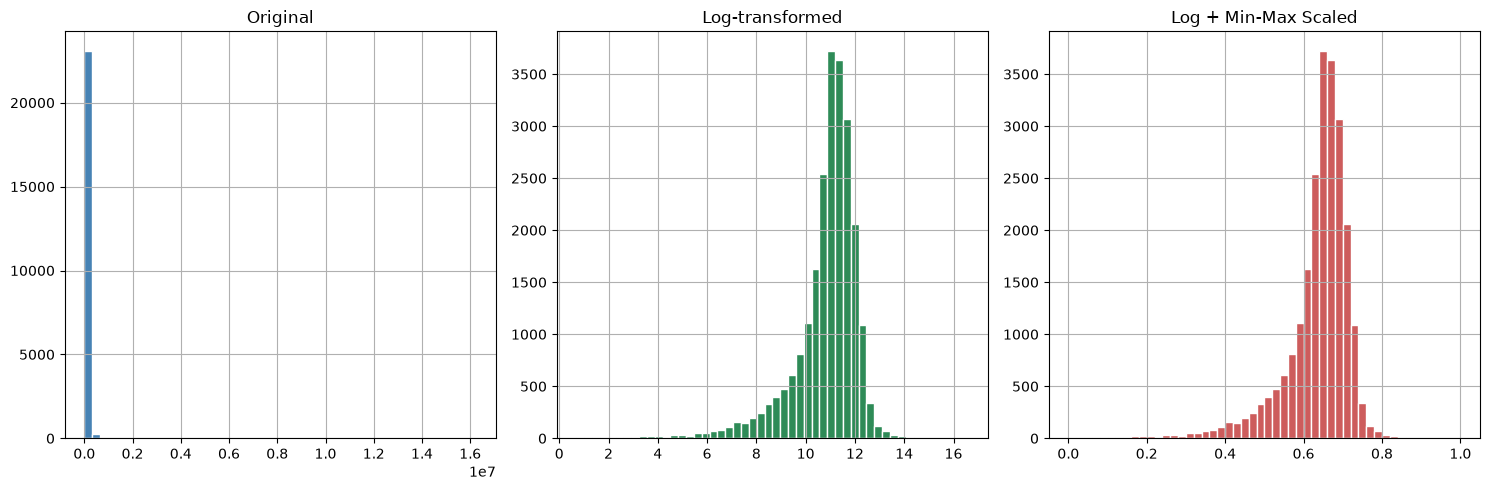

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df['ConvertedCompYearly'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Original')

df['ConvertedCompYearly_log'].dropna().hist(bins=50, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Log-transformed')

df['ConvertedCompYearly_MinMax_experimental'].dropna().hist(bins=50, ax=axes[2], color='indianred', edgecolor='white')
axes[2].set_title('Log + Min-Max Scaled (experimental)')

plt.tight_layout()
plt.show()


### 10. Final Validation

In [15]:
print("Duplicate rows remaining:", df.duplicated().sum())
print("\nMissing values in working columns:")
print(df[key_columns].isnull().sum())
print("\nFinal dataset shape:", df.shape)
print("\nNewly engineered columns:", [
    'Country_clean', 'EdLevel_clean', 'has_compensation_data', 'ExperienceLevel',
    'ConvertedCompYearly_log', 'ConvertedCompYearly_MinMax_experimental', 'ConvertedCompYearly_Zscore_experimental'
])
print("\nNote: 'CompTotal' is retained as-is (not imputed, not transformed) for reference/audit only —"
      " no analysis in Phase 1 or Phase 2 uses it; 'ConvertedCompYearly' is the compensation field used throughout.")


Duplicate rows remaining: 0

Missing values in working columns:
ResponseId                 0
Country                 6507
EdLevel                 4653
Employment                 0
RemoteWork                 0
CodingActivities           0
YearsCodePro           13827
CompTotal              31697
ConvertedCompYearly    42002
dtype: int64

Final dataset shape: (65437, 26)

Newly engineered columns: ['Country_clean', 'EdLevel_clean', 'has_compensation_data', 'ExperienceLevel', 'ConvertedCompYearly_log', 'ConvertedCompYearly_MinMax', 'ConvertedCompYearly_Zscore']


### 11. Export Cleaned Dataset
Save the wrangled core-column dataset so later phases (EDA, modeling) can load it directly instead of re-running this notebook. This is separate from `survey_data_deduplicated_full.csv` saved in Section 2 — use this file when a phase needs exactly these core, fully-wrangled columns; use the full file when it needs a column outside this set.

In [16]:
output_path = f'{DATA_DIR}/survey_data_cleaned_core.csv'
df.to_csv(output_path, index=False)

print(f"Saved {df.shape[0]} rows x {df.shape[1]} columns to '{output_path}'")

Saved 65437 rows x 26 columns to '../data/survey_data_cleaned_core.csv'


### Executive Summary: Data Wrangling Phase
- **Duplicates:** detected and removed from the full raw record before narrowing to the working column set.
- **Missing values:** handled per column — mode imputation for `RemoteWork`, `EdLevel_clean`, and `CodingActivities`; an explicit "Not specified" label for `Country_clean` to avoid geographic bias; `CompTotal` and `ConvertedCompYearly` deliberately left as `NaN` given their very high missing rate, with a `has_compensation_data` flag added instead.
- **Standardization & encoding:** `Country`/`EdLevel` cleaned via mapping; `Employment` one-hot encoded.
- **Feature engineering:** `ExperienceLevel` derived from `YearsCodePro`.
- **Normalization:** `ConvertedCompYearly` skewness reduced via log-transform, with Min-Max and Z-score scaling computed on the transformed values for comparison — saved as `ConvertedCompYearly_MinMax_experimental` / `ConvertedCompYearly_Zscore_experimental` to make clear these are a preliminary trial, not the final scaled features Phase 3 will use.
- **`CompTotal`:** kept in the core file unmodified for reference/audit only (e.g. to spot-check `ConvertedCompYearly`'s USD conversion); it is not used in any analysis in this project.

**Scope note:** this notebook processes the core columns above to demonstrate each wrangling technique end-to-end. The remaining survey columns — including `DevType` and `Industry` — are handled individually as they're brought into later analyses; see Phase 2's README for how each is actually treated.

**Next Steps:** with duplicates removed, the core columns cleaned, encoded, and normalized, and both `data/survey_data_deduplicated_full.csv` (all columns) and `data/survey_data_cleaned_core.csv` (core columns) exported, the dataset is ready for Phase 2: Exploratory Data Analysis — including columns beyond the core set handled in this notebook.
